In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.exp.exp_basic_diffusion import Exp_Basic_Diffusion
from src.exp.exp_diffusion_denoised_x import Exp_Diffusion_Denoised_X
from src.utils.plotting import get_moments, plot_generated_vs_benchmark_moments

working_dir = 'F:\Projects\Ask2.ai\Diffusion'
os.chdir(working_dir)
sns.set_style('whitegrid')

checkpoints_folder= './checkpoints/'
test_folder = './test_results/'

In [2]:
def plot_generated_vs_benchmark_dist(benchmark, data, data_name, save_name=None, bins=100):
    col_labels = benchmark.columns
    main_name = save_name

    num_plots = len(col_labels)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6))
    axes = axes.flatten()
    
    colors = ['red', 'green', 'magenta']

    for i in range(num_plots):
        for j in range(len(data)):
            sns.histplot(data[j].iloc[:, i], bins=bins, color=colors[j], label=data_name[j], kde=True, stat="density", alpha=0.5,
                         ax=axes[i])
        sns.histplot(benchmark.iloc[:, i], bins=bins, color='blue', label='Benchmark', kde=True, stat="density",
                     alpha=0.3, ax=axes[i])

        axes[i].set_title(f'Distribution of {col_labels[i]}')
        axes[i].set_xlabel('Values')
        axes[i].set_ylabel('Density')
        axes[i].legend()

    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(main_name + '_plots.png', dpi=300)
    else:
        plt.show()
    plt.clf()

    return

In [3]:
from statsmodels.tsa.stattools import acf

def plot_generated_vs_benchmark_autocorr(benchmark, data, data_name, save_name=None, absolute=True, lags=20):
    col_labels = benchmark.columns
    main_name = save_name

    num_plots = len(col_labels)
    num_cols = 3
    num_rows = (num_plots + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6))
    axes = axes.flatten()
    
    colors = ['r', 'g', 'm']

    for i in range(num_plots):
        benchmark_ts = abs(benchmark.iloc[:, i]) if absolute else benchmark.iloc[:, i]
        acf_benchmark = acf(benchmark_ts, nlags=lags)[1:]
        
        for j in range(len(data)):
            output_ts = abs(data[j].iloc[:, i]) if absolute else data[j].iloc[:, i]
            acf_output = acf(output_ts, nlags=lags)[1:]
            acf_output = np.nan_to_num(acf_output, nan=0.0)
            stem_output = axes[i].stem(range(1, len(acf_output) + 1), acf_output, 
                           linefmt=f"{colors[j]}-", markerfmt=f"{colors[j]}o", 
                           basefmt=" ", label=data_name[j])
            plt.setp(stem_output[0], alpha=0.7)  # Line style
            plt.setp(stem_output[1], alpha=0.9)

        stem_benchmark = axes[i].stem(range(1, len(acf_benchmark) + 1), acf_benchmark, linefmt='b-', markerfmt='bo',
                                      basefmt=" ", label='Benchmark')
        plt.setp(stem_benchmark[0], alpha=0.7)
        plt.setp(stem_benchmark[1], alpha=0.9)

        axes[i].set_title(f'ACF of {col_labels[i]}')
        axes[i].set_xlabel('Lags')
        axes[i].set_ylabel('Autocorrelation')
        axes[i].legend()

    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()

    if save_name is not None:
        plt.savefig(main_name + '_plots.png', dpi=300)
    else:
        plt.show()
    plt.clf()

    return

# Vanilla Diffusion vs Our Models

In [12]:
best_results = pd.DataFrame(
    columns=['Diffusion', 'Model', 'Loss', 'Step', 'Mean_MSE', 'Std_MSE','Skewness_MSE','Kurtosis_MSE','M_KL_Div','Auto-Corr_DTW','Covariance_Riemannian','Correlation_Riemannian'])
best_results['Diffusion'] = ['Vanilla Diffusion', 'Vanilla Diffusion', 'Diffusion Denoised']
best_results['Model'] = ['UNet', 'UniTST_MP', 'UniTST_MP']
best_results['Loss'] = ['MSE', 'MSE', 'KL+Corr+MSE']

In [13]:
model_folder = 'basic_diffusion_UNet_ALL_Benchmark_MSE_N_sl128/'
best_step_folder = '600_discrete_DDPM_1.0000/'
df_benchmark = pd.read_csv(test_folder + model_folder + 'benchmark_data.csv')
df_benchmark = df_benchmark.iloc[:, 1:].reset_index(drop=True)
df_generated_1 = pd.read_csv(test_folder + model_folder + best_step_folder + 'generated_data.csv')
df_results_1 = pd.read_csv(test_folder + model_folder + 'results_discrete_DDPM_1.0.csv')
best_results.iloc[0, 3:] = df_results_1.iloc[5, :]

In [17]:
model_folder = 'basic_diffusion_UniTST_MP_ALL_Benchmark_MSE_N_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE/'
best_step_folder = '600_discrete_DDPM_1.0000/'
df_generated_2 = pd.read_csv(test_folder + model_folder + best_step_folder + 'generated_data.csv')
df_results_2 = pd.read_csv(test_folder + model_folder + 'results_discrete_DDPM_1.0.csv')
best_results.iloc[1, 3:] = df_results_2.iloc[5, :]

In [18]:
model_folder = 'diffusion_denoised_x_UniTST_MP_ALL_Benchmark_KL2_N+Corr+FFT_sl128_ds0_cmTrue_ceTrue_ipTrue_RoPE/'
best_step_folder = '500_discrete_DDPM_0.7473/'
df_generated_3 = pd.read_csv(test_folder + model_folder + best_step_folder + 'generated_data.csv')
df_results_3 = pd.read_csv(test_folder + model_folder + 'results_discrete_DDPM_0.7473231454237225.csv')
best_results.iloc[2, 3:] = df_results_3.iloc[4, :]

In [19]:
best_results

,Diffusion,Model,Loss,Step,Mean_MSE,Std_MSE,Skewness_MSE,Kurtosis_MSE,M_KL_Div,Auto-Corr_DTW,Covariance_Riemannian,Correlation_Riemannian
0,Vanilla Diffusion,UNet,MSE,600.0,0.00001,0.000083,1.121977,1286.811571,0.535895,0.505292,8.387909,4.604574
1,Vanilla Diffusion,UniTST_MP,MSE,600.0,0.0,0.00002,0.614104,709.456615,0.253553,0.634113,6.363963,4.162863
2,Diffusion Denoised,UniTST_MP,KL+Corr+MSE,500.0,0.000011,0.000017,12.802062,1509.02384,0.26882,0.701388,4.339017,2.919471


In [22]:
best_results.to_csv('./comparison_results/vary_configs/performance_comparison.csv', index=False)

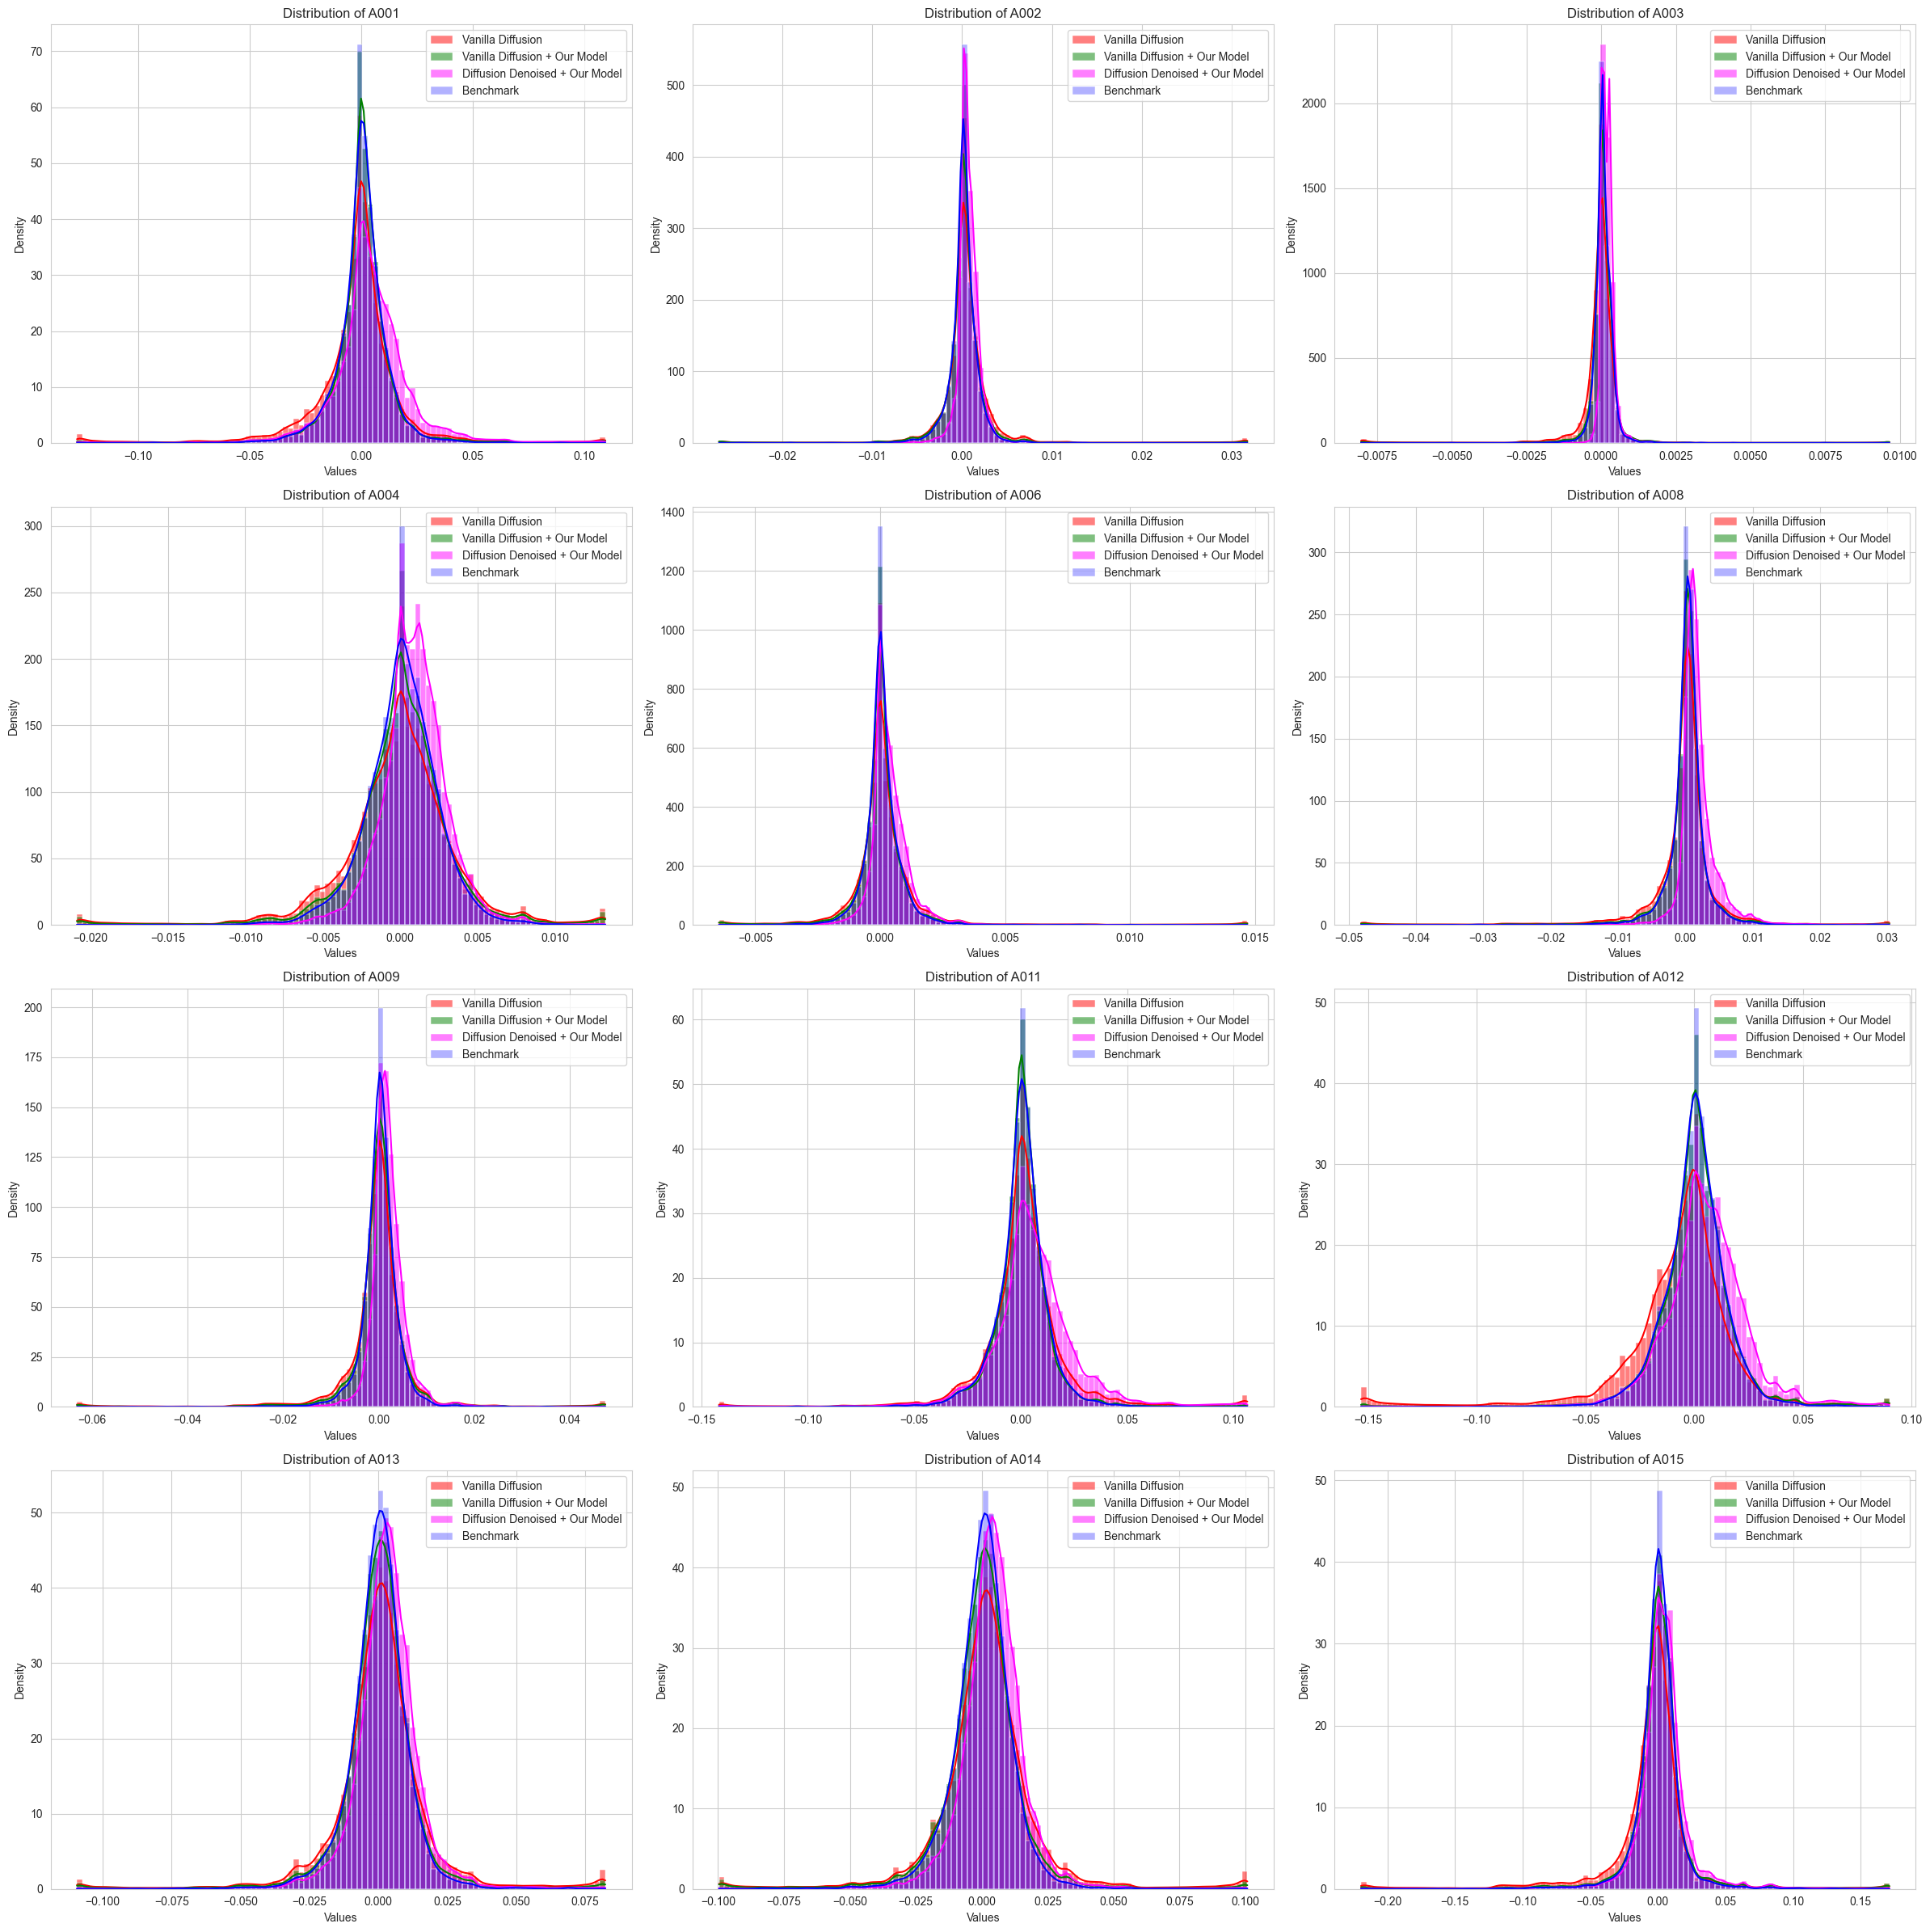

<Figure size 640x480 with 0 Axes>

In [20]:
data_list = [df_generated_1, df_generated_2, df_generated_3]
data_name = ['Vanilla Diffusion', 'Vanilla Diffusion + Our Model', 'Diffusion Denoised + Our Model']
plot_generated_vs_benchmark_dist(df_benchmark, data_list, data_name)

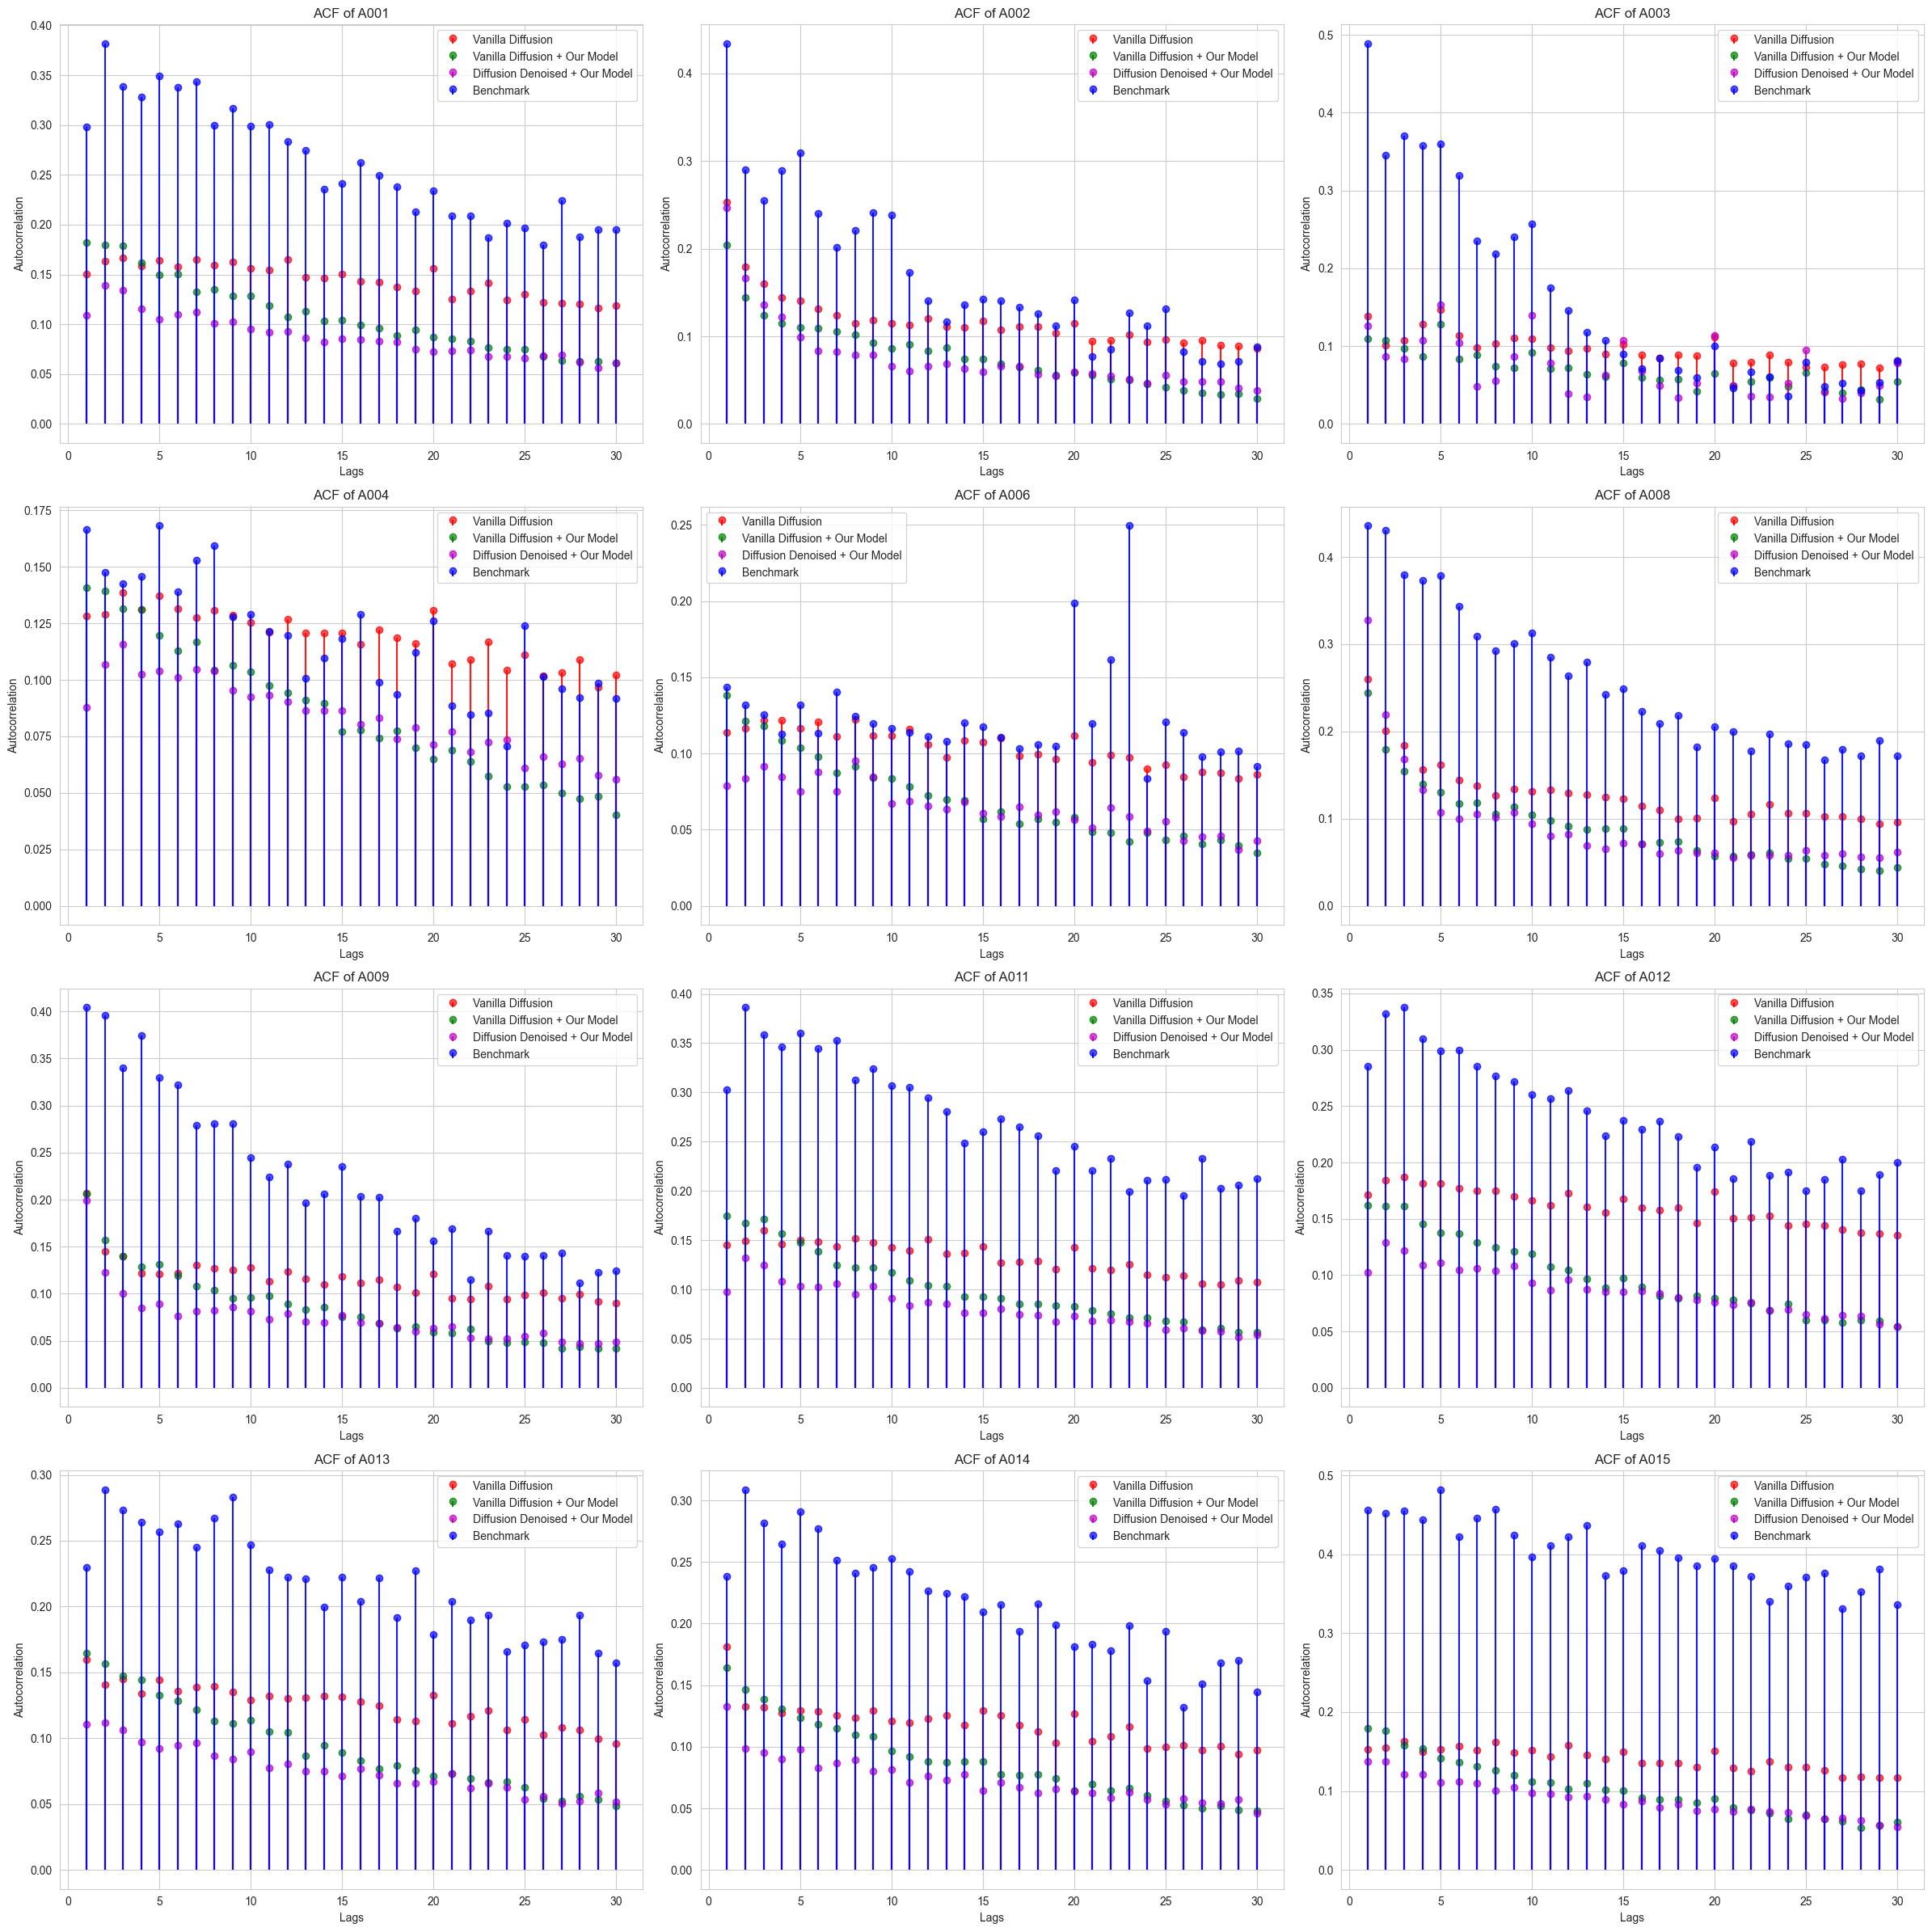

<Figure size 640x480 with 0 Axes>

In [21]:
plot_generated_vs_benchmark_autocorr(df_benchmark, data_list, data_name, absolute=True, lags=30)

# Different Quantile Transformation Bins

In [ ]:
best_results = pd.DataFrame(
    columns=['Bins', 'Step', 'Mean_MSE', 'Std_MSE','Skewness_MSE','Kurtosis_MSE','M_KL_Div','Auto-Corr_DTW','Covariance_Riemannian','Correlation_Riemannian'])
best_results['Bins'] = ['1000', '500', '100']

In [ ]:
# Vanilla 1000
model_folder = 'basic_diffusion_UNet_ALL_Benchmark_MSE_N_sl128/'
best_step_folder = '600_discrete_DDPM_1.0000/'
df_benchmark = pd.read_csv(test_folder + model_folder + 'benchmark_data.csv')
df_benchmark = df_benchmark.iloc[:, 1:].reset_index(drop=True)
df_generated_1 = pd.read_csv(test_folder + model_folder + best_step_folder + 'generated_data.csv')
df_results_1 = pd.read_csv(test_folder + model_folder + 'results_discrete_DDPM_1.0.csv')
best_results.iloc[0, 1:] = df_results_1.iloc[5, :]

In [ ]:
# Vanilla 500
model_folder = 'basic_diffusion_UNet_ALL_Benchmark_MSE_N_sl128_quantile_bins_500/'
best_step_folder = '600_discrete_DDPM_1.0000/'
df_generated_2 = pd.read_csv(test_folder + model_folder + best_step_folder + 'generated_data.csv')
df_results_2 = pd.read_csv(test_folder + model_folder + 'results_discrete_DDPM_1.0.csv')
best_results.iloc[1, 1:] = df_results_2.iloc[5, :]

In [ ]:
# Vanilla 100
model_folder = 'basic_diffusion_UNet_ALL_Benchmark_MSE_N_sl128_quantile_bins_100/'
best_step_folder = '600_discrete_DDPM_1.0000/'
df_generated_3 = pd.read_csv(test_folder + model_folder + best_step_folder + 'generated_data.csv')
df_results_3 = pd.read_csv(test_folder + model_folder + 'results_discrete_DDPM_1.0.csv')
best_results.iloc[2, 1:] = df_results_3.iloc[5, :]

In [ ]:
best_results.to_csv('./comparison_results/vary_bins/performance_comparison.csv', index=False)

In [ ]:
data_list = [df_generated_1, df_generated_2, df_generated_3]
data_name = ['Bins: 1000', 'Bins: 500', 'Bins: 100']
plot_generated_vs_benchmark_dist(df_benchmark, data_list, data_name)

In [ ]:
plot_generated_vs_benchmark_autocorr(df_benchmark, data_list, data_name, absolute=True, lags=30)